# Composite: **misc_americano** (background) + **torchocolate** (insert)

**Prerequisites**

1. Run `americano_generate_delete_mask.ipynb` — writes a **DELETE** mask for the café scene (`mask_table[t,n]==True` → **keep** Gaussian `n` at frame `t`).
2. Foreground mask: `only_chocolate_foil.pt` (chocolate-only selection on torchocolate). If you **swap in** a post-processed PLY (e.g. darker chocolate), keep the **same** Gaussian count as the trained checkpoint so the mask still aligns.

**Outputs:** After the export cell you get a composite **PLY** + **`.pt`** mask on disk under `misc_americano/` for harmonization / your pipeline.

In [ ]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import imageio
import numpy as np
import torch
from tqdm import tqdm
from argparse import ArgumentParser
from matplotlib import pyplot as plt
from arguments import ModelParams, PipelineParams, ModelHiddenParams
from utils.segment_utils import get_combined_args
from utils.transform_utils_torch import (
    init_dynamic_gaussians, render, to8b
)
import mmcv
from utils.params_utils import merge_hparams

%load_ext autoreload
%autoreload 2
print('Imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


## 1. Paths — edit masks / optional darker-chocolate PLY

`MASK0` must match the `.pt` filename produced by `americano_generate_delete_mask.ipynb` (default name pattern shown below).

Set `CHOC_PLY_OVERRIDE` to your baked edit (e.g. `scene_point_cloud_CHOCOPY_v02_flat055_dark24.ply`), or `None` to use the trained checkpoint PLY from disk.

In [52]:
# ── Models ──
MODEL0   = './output/hypernerf/misc_americano'     # background (café)
MODEL1   = './output/hypernerf/torchocolate'       # foreground object
CFG_PATH = './arguments/hypernerf/default.py'

EXPORT_TAG = 'v01'   # bumps filenames when you iterate

# Preview / debug renders
RUN_TAG     = f'americano_choc_{EXPORT_TAG}'
RENDER_PATH = f'./output/composite_{RUN_TAG}'
os.makedirs(RENDER_PATH, exist_ok=True)

# ── Mask tables ──
# Background: KEEP mask from americano_generate_delete_mask.ipynb (same mc/q as you used there).
MASK0 = './output/hypernerf/misc_americano/segment_results/misc_americano_delete_rulesumprob_mc0.8_mrp0.35_noq_norad.pt'

# Foreground: existing chocolate-only mask on torchocolate.
MASK1 = './output/hypernerf/torchocolate/segment_results/only_chocolate_foil.pt'

# Optional: darker / flattened chocolate PLY (same #Gaussians as training). Example:
# CHOC_PLY_OVERRIDE = './output/hypernerf/torchocolate/point_cloud/iteration_14000/scene_point_cloud_CHOCOPY_v02_flat055_dark24.ply'
CHOC_PLY_OVERRIDE = None

# ── Export targets (written under misc_americano) ──
EXPORT_PLY_PATH = os.path.join(
    MODEL0, 'point_cloud', 'iteration_14000',
    f'composite_misc_americano_plus_choc_{EXPORT_TAG}.ply'
)
EXPORT_MASK_PATH = os.path.join(
    MODEL0, 'segment_results',
    f'composite_inserted_choc_{EXPORT_TAG}.pt'
)

for label, path in [('MASK0 (bg delete→keep)', MASK0), ('MASK1 (chocolate)', MASK1)]:
    if os.path.exists(path):
        print(f'  ✓ {label}: {path}')
    else:
        raise FileNotFoundError(f'✗ {label}: MISSING — fix path: {path}')

if CHOC_PLY_OVERRIDE:
    if os.path.isfile(CHOC_PLY_OVERRIDE):
        print(f'  ✓ CHOC_PLY_OVERRIDE: {CHOC_PLY_OVERRIDE}')
    else:
        print(f'  ⚠ CHOC_PLY_OVERRIDE set but file not found (will skip): {CHOC_PLY_OVERRIDE}')

  ✓ MASK0 (bg delete→keep): ./output/hypernerf/misc_americano/segment_results/misc_americano_delete_rulesumprob_mc0.8_mrp0.35_noq_norad.pt
  ✓ MASK1 (chocolate): ./output/hypernerf/torchocolate/segment_results/only_chocolate_foil.pt


## 2. Load both scenes (`scene` mode)

In [53]:
def load_scene(model_path, cfg_path):
    parser = ArgumentParser()
    model_p = ModelParams(parser, sentinel=True)
    hp = ModelHiddenParams(parser)
    parser.add_argument('--iteration', default=-1, type=int)
    parser.add_argument('--configs', type=str, default=cfg_path)

    args = get_combined_args(parser, model_path, 'scene')
    config = mmcv.Config.fromfile(args.configs)
    args = merge_hparams(args, config)
    args.object_masks = False
    args.need_gt_masks = False

    gaussians, scene, background = init_dynamic_gaussians(
        model_p.extract(args), hp.extract(args), args.iteration
    )
    return gaussians, scene, background

print('Loading misc_americano...')
gaussians0, scene0, background = load_scene(MODEL0, CFG_PATH)

print('Loading torchocolate...')
gaussians1, scene1, _ = load_scene(MODEL1, CFG_PATH)

if CHOC_PLY_OVERRIDE and os.path.isfile(CHOC_PLY_OVERRIDE):
    print('Applying CHOC_PLY_OVERRIDE (same Gaussian count as checkpoint required)...')
    gaussians1.load_ply(CHOC_PLY_OVERRIDE)
    print(f'  torchocolate Gaussians after PLY load: {gaussians1.get_xyz.shape[0]}')


Loading misc_americano...
Looking for config file in ./output/hypernerf/misc_americano/cfg_args
Config file found at: ./output/hypernerf/misc_americano/cfg_args
mode:  scene
Loading trained model at iteration 14000
load finished


132it [00:00, 61984.79it/s]

format finished


Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [ 7.9026313  6.572209  32.661182 ] [-10.831657 -20.024147  16.978903]
Voxel Plane: set aabb= Parameter containing:
tensor([[  7.9026,   6.5722,  32.6612],
        [-10.8317, -20.0241,  16.9789]])
loading model from exists./output/hypernerf/misc_americano/point_cloud/iteration_14000
Init ./output/hypernerf/misc_americano finished

Loading torchocolate...
Looking for config file in ./output/hypernerf/torchocolate/cfg_args
Config file found at: ./output/hypernerf/torchocolate/cfg_args
mode:  scene
Loading trained model at iteration 14000
load finished


174it [00:00, 62574.71it/s]

format finished
Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [47.76659775 31.60019684 94.26104736] [-54.118927   -65.01464844   9.57078719]
Voxel Plane: set aabb= Parameter containing:
tensor([[ 47.7666,  31.6002,  94.2610],
        [-54.1189, -65.0146,   9.5708]])


loading model from exists./output/hypernerf/torchocolate/point_cloud/iteration_14000
Init ./output/hypernerf/torchocolate finished



## 3. Load mask tables

In [54]:
gaussians1.load_mask_table(MASK1)
print(
    f'torchocolate mask: {gaussians1._mask_table.shape}  '
    f'(avg selected / frame: {gaussians1._mask_table.float().sum(dim=1).mean():.0f})'
)

gaussians0.load_mask_table(MASK0)
USE_BG_DELETE_MASK = True
print(f'misc_americano mask: {gaussians0._mask_table.shape}')

N_expect = gaussians1.get_xyz.shape[0]
if gaussians1._mask_table.shape[1] != N_expect:
    raise RuntimeError(
        f'MASK1 width {gaussians1._mask_table.shape[1]} != Gaussians {N_expect}. '
        'Use a PLY with the same count as the mask, or regenerate MASK1.'
    )


torchocolate mask: torch.Size([174, 246117])  (avg selected / frame: 1411)
misc_americano mask: torch.Size([132, 366377])


### Optional: scale change compensation

If you only change `scales_bias1`, the object can appear to drift because scaling is about the origin. Uncomment / adapt from `composite_cookie_choc.ipynb` cell 8 if needed.

In [ ]:
# Optional — leave commented unless you use the scale-compensation trick from the cookie notebook.
# with torch.no_grad():
#     obj_center = gaussians1.get_xyz.mean(dim=0).cpu()
# s_old, s_new = 0.5, 0.7
# compensation = obj_center * (s_old - s_new)
# base_offset = torch.tensor([1.0, -1.8, 2.0])
# motion_bias1 = base_offset + compensation
# scales_bias1 = float(s_new)
# print(motion_bias1, scales_bias1)
pass


[data_loading] Mask table: 132 frames, 366377 gaussians, 85.1% active
Wrote cleaned MASK0 -> ./output/hypernerf/misc_americano/segment_results/misc_americano_delete_rulesumprob_mc0.8_mrp0.35_noq_norad_post_mf0.2_k16_r0.06.pt
[data_loading] Mask table: 174 frames, 246117 gaussians, 0.6% active
Wrote cleaned MASK1 -> ./output/hypernerf/torchocolate/segment_results/only_chocolate_foil_post_mf0.2_k16_r0.06.pt


## 4. Single-frame composite — set rough transform, then refine in §5

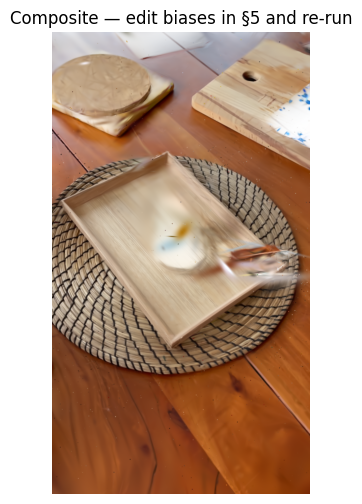

In [56]:
# gaussians[0] = misc_americano (bg), gaussians[1] = torchocolate (fg)

scales_bias0   = 1.0
rotation_bias0 = torch.tensor([0.0, 0.0, 0.0])
motion_bias0   = torch.tensor([0.0, 0.0, 0.0])

scales_bias1   = 0.5
rotation_bias1 = torch.tensor([0.0, 0.0, 0.0])
motion_bias1   = torch.tensor([1.0, -1.8, 2.0])

gaussians = [gaussians0, gaussians1]

train_cams0 = scene0.getTrainCameras()
test_view   = train_cams0[0]
timestamp   = test_view.time

seg_flags    = [USE_BG_DELETE_MASK, True]
static_flags = [False, False]

with torch.no_grad():
    result = render(
        test_view, timestamp,
        gaussians,
        bg_color     = background,
        motion_bias  = [motion_bias0,   motion_bias1],
        rotation_bias= [rotation_bias0, rotation_bias1],
        scales_bias  = [scales_bias0,   scales_bias1],
        static       = static_flags,
        seg          = seg_flags,
        bg           = True
    )

plt.figure(figsize=(8, 6))
plt.imshow(to8b(result['render']).transpose(1, 2, 0))
plt.title('Composite — edit biases in §5 and re-run')
plt.axis('off')
plt.show()


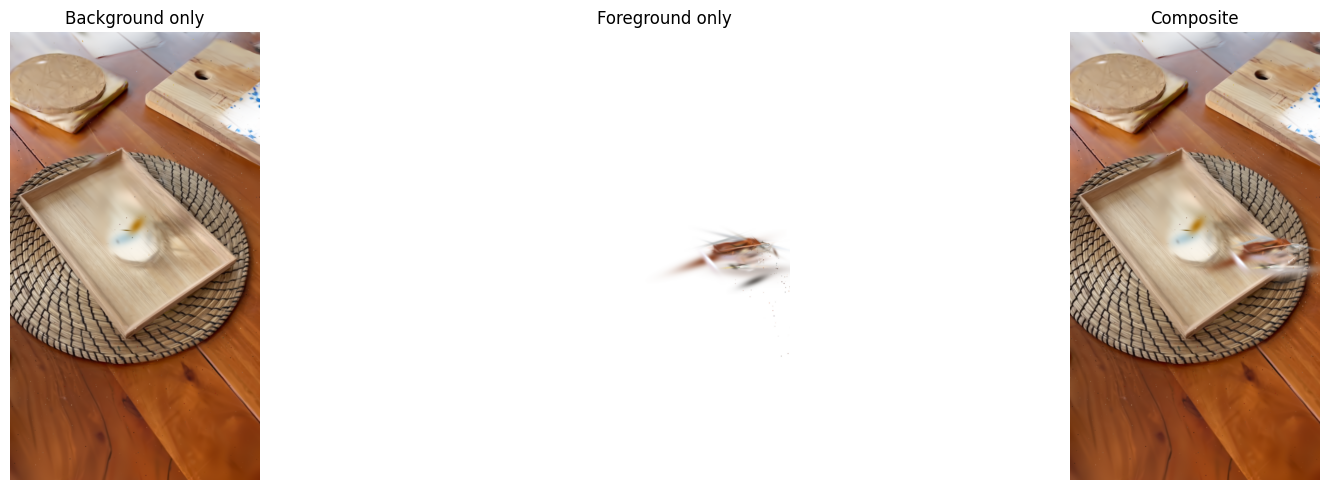

In [57]:
# Background / foreground / composite
with torch.no_grad():
    result_bg = render(
        test_view, timestamp,
        [gaussians0], background,
        motion_bias=[motion_bias0], rotation_bias=[rotation_bias0],
        scales_bias=[scales_bias0], static=[False], seg=[USE_BG_DELETE_MASK], bg=True
    )

    result_fg = render(
        test_view, timestamp,
        [gaussians0, gaussians1], background,
        motion_bias=[motion_bias0, motion_bias1],
        rotation_bias=[rotation_bias0, rotation_bias1],
        scales_bias=[scales_bias0, scales_bias1],
        static=[False, False], seg=[USE_BG_DELETE_MASK, True], bg=False
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(to8b(result_bg['render']).transpose(1, 2, 0))
axes[0].set_title('Background only'); axes[0].axis('off')
axes[1].imshow(to8b(result_fg['render']).transpose(1, 2, 0))
axes[1].set_title('Foreground only'); axes[1].axis('off')
axes[2].imshow(to8b(result['render']).transpose(1, 2, 0))
axes[2].set_title('Composite'); axes[2].axis('off')
plt.tight_layout()
plt.show()


## 5. Tune transforms (camera-relative nudges)

Adjust `base_offset1`, `d_right` / `d_up` / `d_forward`, `scales_bias1`, `rotation_bias1` until placement looks right on several `VIEW_IDX` values.

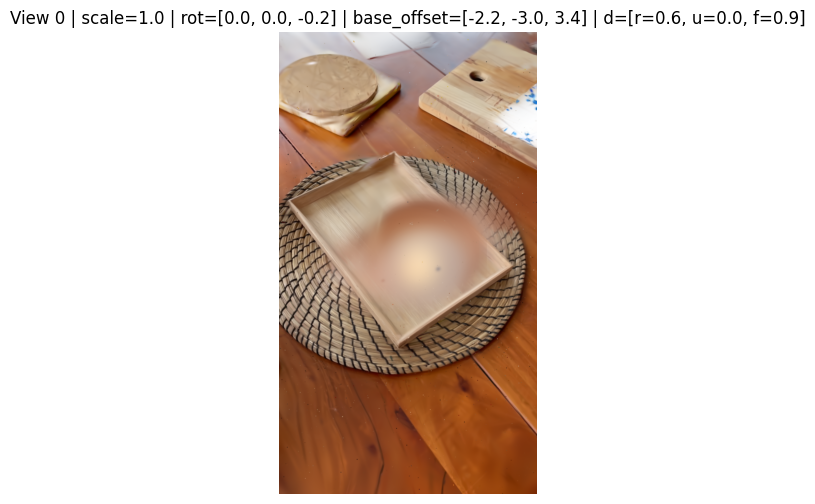

In [ ]:
import torch.nn.functional as F
import ipywidgets as widgets
from IPython.display import display

# Interactive placement UI (preview from different cameras).
# Writes back to these globals for later export cells:
#   motion_bias1 / rotation_bias1 / scales_bias1 / base_offset1 / VIEW_IDX

def camera_axes_world(cam):
    """Return normalized (right, up, forward) axes in WORLD coords for this camera."""
    W2C = cam.world_view_transform.cuda()
    C2W = torch.inverse(W2C)
    right = C2W[:3, 0]
    up = C2W[:3, 1]
    forward = -C2W[:3, 2]
    return F.normalize(right, dim=0), F.normalize(up, dim=0), F.normalize(forward, dim=0)

n_views = len(train_cams0)

view_idx_w = widgets.IntSlider(value=0, min=0, max=max(0, n_views - 1), step=1, description='view')

# Base offset in WORLD coords
base_x_w = widgets.FloatSlider(value=-2.2, min=-10.0, max=10.0, step=0.05, description='base_x')
base_y_w = widgets.FloatSlider(value=-3.0, min=-10.0, max=10.0, step=0.05, description='base_y')
base_z_w = widgets.FloatSlider(value=3.4, min=-10.0, max=10.0, step=0.05, description='base_z')

# Camera-relative translation (right/up/forward)
d_right_w = widgets.FloatSlider(value=0.6, min=-5.0, max=5.0, step=0.02, description='right')
d_up_w = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.02, description='up')
d_forward_w = widgets.FloatSlider(value=0.9, min=-5.0, max=5.0, step=0.02, description='forward')

# Scale + rotation (radians)
scale_w = widgets.FloatSlider(value=1.0, min=0.05, max=3.0, step=0.01, description='scale')
rx_w = widgets.FloatSlider(value=0.0, min=-3.1416, max=3.1416, step=0.01, description='rx')
ry_w = widgets.FloatSlider(value=0.0, min=-3.1416, max=3.1416, step=0.01, description='ry')
rz_w = widgets.FloatSlider(value=-0.20, min=-3.1416, max=3.1416, step=0.01, description='rz')

quality_w = widgets.Dropdown(options=[('fast', 0.5), ('normal', 1.0)], value=1.0, description='quality')

out = widgets.Output()


def _render_preview(*_):
    global scales_bias1, rotation_bias1, motion_bias1, base_offset1, VIEW_IDX

    VIEW_IDX = int(view_idx_w.value)
    view = train_cams0[VIEW_IDX]

    right, up, forward = camera_axes_world(view)

    base_offset1 = torch.tensor([base_x_w.value, base_y_w.value, base_z_w.value], device='cuda')

    motion_bias1 = (
        base_offset1
        + float(d_right_w.value) * right
        + float(d_up_w.value) * up
        + float(d_forward_w.value) * forward
    )

    rotation_bias1 = torch.tensor([float(rx_w.value), float(ry_w.value), float(rz_w.value)], device='cuda')
    scales_bias1 = float(scale_w.value)

    with out:
        out.clear_output(wait=True)
        with torch.no_grad():
            result = render(
                view, view.time, gaussians, background,
                motion_bias=[motion_bias0, motion_bias1],
                rotation_bias=[rotation_bias0, rotation_bias1],
                scales_bias=[scales_bias0, scales_bias1],
                static=static_flags,
                seg=seg_flags,
                bg=True,
                scaling_modifier=float(quality_w.value),
            )

        plt.figure(figsize=(8, 6))
        plt.imshow(to8b(result['render']).transpose(1, 2, 0))
        plt.title(
            f'view={VIEW_IDX} | scale={scales_bias1:.3f} | '
            f'rot={[round(float(x), 3) for x in rotation_bias1.detach().cpu()]} | '
            f'motion={[round(float(x), 3) for x in motion_bias1.detach().cpu()]}'
        )
        plt.axis('off')
        plt.show()


for w in [view_idx_w, base_x_w, base_y_w, base_z_w, d_right_w, d_up_w, d_forward_w, scale_w, rx_w, ry_w, rz_w, quality_w]:
    w.observe(_render_preview, names='value')

ui = widgets.VBox([
    widgets.HBox([view_idx_w, quality_w]),
    widgets.HTML('<b>Translate (camera-relative)</b>'),
    widgets.HBox([d_right_w, d_up_w, d_forward_w]),
    widgets.HTML('<b>Base offset (world)</b>'),
    widgets.HBox([base_x_w, base_y_w, base_z_w]),
    widgets.HTML('<b>Scale + Rotate (radians)</b>'),
    widgets.HBox([scale_w, rx_w, ry_w, rz_w]),
])

display(ui, out)
_render_preview()


## 6. (Optional) Render a preview video — misc_americano camera path

In [48]:
import imageio.v2 as imageio
import gc

out_path = os.path.join(RENDER_PATH, f'composite_misc_americano_choc_{EXPORT_TAG}.mp4')
video_cams0 = scene0.getVideoCameras()

writer = imageio.get_writer(out_path, fps=30, quality=8)
torch.cuda.empty_cache()
gc.collect()

print(f'Starting render of {len(video_cams0)} frames...')

with torch.no_grad():
    for idx, viewpoint in enumerate(tqdm(video_cams0)):
        res = render(
            viewpoint, viewpoint.time, gaussians, background,
            motion_bias  = [motion_bias0,   motion_bias1],
            rotation_bias= [rotation_bias0, rotation_bias1],
            scales_bias  = [scales_bias0,   scales_bias1],
            static       = static_flags,
            seg          = seg_flags,
            bg           = True
        )
        frame = to8b(res['render']).transpose(1, 2, 0)
        writer.append_data(frame)
        del res, frame
        if idx % 50 == 0:
            torch.cuda.empty_cache()

writer.close()
torch.cuda.empty_cache()
print(f'Done → {out_path}')


Starting render of 131 frames...


  0%|          | 0/131 [00:00<?, ?it/s]IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (536, 960) to (544, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
526it [01:41,  5.18it/s]                         


Done → ./output/composite_americano_choc_v01/composite_misc_americano_choc_v01.mp4


## 7. Export composite PLY + insert mask (for harmonize / pipeline)

Same logic as `composite_cookie_choc.ipynb`: background Gaussians not in the KEEP delete-mask get opacity pushed to `-100`; foreground Gaussians (mask1) are transformed and appended. The saved `mask_table` is **True** only on the **appended** indices for harmonization.

In [ ]:
import os
import torch
import numpy as np
from plyfile import PlyData, PlyElement
from utils.transform_utils_torch import transform

if not hasattr(gaussians0, '_mask_table'):
    raise RuntimeError('Background has no _mask_table (load MASK0).')
if not hasattr(gaussians1, '_mask_table'):
    raise RuntimeError('Foreground has no _mask_table (load MASK1).')

bg_keep_any = gaussians0._mask_table.any(dim=0).bool()
fg_keep_any = gaussians1._mask_table.any(dim=0).bool()

N_bg = int(gaussians0._xyz.shape[0])
N_fg_sel = int(fg_keep_any.sum().item())

xyz_bg = gaussians0._xyz.detach()
feat_dc_bg = gaussians0._features_dc.detach()
feat_rest_bg = gaussians0._features_rest.detach()
scaling_bg = gaussians0._scaling.detach()
rotation_bg = gaussians0._rotation.detach()
opacity_bg = gaussians0._opacity.detach().clone()

removed = ~bg_keep_any
opacity_bg[removed] = -100.0

with torch.no_grad():
    xyz_fg_raw = gaussians1._xyz[fg_keep_any].detach().clone()
    scaling_fg_act = gaussians1.scaling_activation(gaussians1._scaling[fg_keep_any].detach().clone())
    rotation_fg_act = gaussians1.rotation_activation(gaussians1._rotation[fg_keep_any].detach().clone())

    mb = motion_bias1.to('cuda') if not motion_bias1.is_cuda else motion_bias1
    rb = rotation_bias1.to('cuda') if not rotation_bias1.is_cuda else rotation_bias1
    sb = float(scales_bias1)

    xyz_fg_t, rotation_fg_t, scaling_fg_t = transform(
        xyz_fg_raw, rotation_fg_act, scaling_fg_act, sb, mb, rb
    )

    scaling_fg_log = torch.log(scaling_fg_t.clamp(min=1e-8))
    rotation_fg_store = rotation_fg_t

feat_dc_fg = gaussians1._features_dc[fg_keep_any].detach()
feat_rest_fg = gaussians1._features_rest[fg_keep_any].detach()
opacity_fg = gaussians1._opacity[fg_keep_any].detach()

xyz = torch.cat([xyz_bg, xyz_fg_t.cuda()], dim=0).cpu().numpy()
normals = np.zeros_like(xyz)

f_dc = torch.cat([
    feat_dc_bg.transpose(1, 2).flatten(start_dim=1),
    feat_dc_fg.transpose(1, 2).flatten(start_dim=1)
], dim=0).cpu().numpy()

f_rest = torch.cat([
    feat_rest_bg.transpose(1, 2).flatten(start_dim=1),
    feat_rest_fg.transpose(1, 2).flatten(start_dim=1)
], dim=0).cpu().numpy()

opacities = torch.cat([opacity_bg, opacity_fg], dim=0).cpu().numpy()
scale = torch.cat([scaling_bg, scaling_fg_log.cuda()], dim=0).cpu().numpy()
rot = torch.cat([rotation_bg, rotation_fg_store.cuda()], dim=0).cpu().numpy()

dtype_full = [(a, 'f4') for a in gaussians0.construct_list_of_attributes()]
elements = np.empty(xyz.shape[0], dtype=dtype_full)
attributes = np.concatenate((xyz, normals, f_dc, f_rest, opacities, scale, rot), axis=1)
elements[:] = list(map(tuple, attributes))

os.makedirs(os.path.dirname(EXPORT_PLY_PATH), exist_ok=True)
PlyData([PlyElement.describe(elements, 'vertex')]).write(EXPORT_PLY_PATH)

T = int(gaussians0._mask_table.shape[0])
N_total = int(xyz.shape[0])
inserted = torch.zeros((N_total,), dtype=torch.bool)
inserted[N_bg:] = True
mask_table = inserted.unsqueeze(0).repeat(T, 1)

mask_payload = {
    'mask_table': mask_table,
    'time_map': gaussians0._time_map if hasattr(gaussians0, '_time_map') else torch.linspace(0, 1, T),
}

os.makedirs(os.path.dirname(EXPORT_MASK_PATH), exist_ok=True)
torch.save(mask_payload, EXPORT_MASK_PATH)

print(f'✅ Wrote composite PLY:  {EXPORT_PLY_PATH}  (N_bg={N_bg}, N_fg_sel={N_fg_sel}, N_total={N_total})')
print(f'✅ Wrote composite mask: {EXPORT_MASK_PATH}  (shape={tuple(mask_table.shape)})')
print(f'   Baked: scale={sb}, rotation={[round(float(x),3) for x in rb]}, offset={[round(float(x),3) for x in mb]}')
